In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# Load POSCAR structure
poscar_file = "../4_volume+position_opt/CONTCAR"
atoms = read(poscar_file)

# Print basic info
print(f"Chemical Formula: {atoms.get_chemical_formula()}")
print(f"Total Atoms: {len(atoms)}")
print(f"Cell Parameters (a, b, c in Å):\n{atoms.cell.cellpar()[:3].round(3)}")

Chemical Formula: Mo12Ta12Ti12V12W12
Total Atoms: 60
Cell Parameters (a, b, c in Å):
[9.886 9.886 9.886]


In [2]:
from ase.geometry.analysis import Analysis

# 1. Settings for RDF
rmax = 4.6      # Maximum distance to inspect (in Å)
nbins = 200     # Resolution: bin width = 6.0 / 200 = 0.03 Å

# 2. Compute Total RDF
ana = Analysis(atoms)
rdf_data = ana.get_rdf(rmax=rmax, nbins=nbins)[0]

# 3. Create distance axis (r values in Å)
dr = rmax / nbins
r = np.linspace(dr / 2, rmax - dr / 2, nbins)

Optimal 1NN Cutoff Radius: 2.840 Å


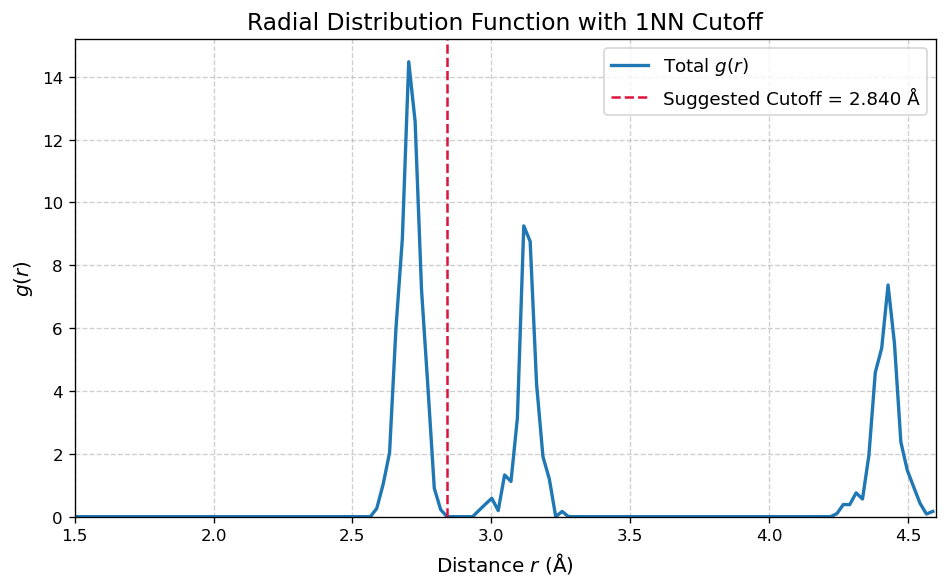

In [3]:
# Search for the minimum between the 1NN peak (~2.7 Å) and 2NN peak (~3.1 Å)
# We limit the search range between 2.8 Å and 3.3 Å
search_mask = (r >= 2.8) & (r <= 3.3)
r_search = r[search_mask]
rdf_search = rdf_data[search_mask]

# Find the distance where g(r) is lowest in that interval
r_cutoff = r_search[np.argmin(rdf_search)]

print(f"Optimal 1NN Cutoff Radius: {r_cutoff:.3f} Å")

# Plot with the cutoff marked
plt.figure(figsize=(8, 5), dpi=120)
plt.plot(r, rdf_data, color="#1f77b4", linewidth=2, label="Total $g(r)$")
plt.axvline(r_cutoff, color="crimson", linestyle="--", linewidth=1.5, 
            label=f"Suggested Cutoff = {r_cutoff:.3f} Å")

plt.title("Radial Distribution Function with 1NN Cutoff", fontsize=14)
plt.xlabel("Distance $r$ (Å)", fontsize=12)
plt.ylabel("$g(r)$", fontsize=12)
plt.xlim(1.5, rmax)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from ase.neighborlist import neighbor_list

def calculate_warren_cowley(atoms, r_cut):
    """
    Calculates 1st shell Warren-Cowley parameters for a multicomponent system.
    
    Parameters:
    -----------
    atoms : ase.Atoms
        Structure loaded from POSCAR.
    r_cut : float
        Cutoff radius (Å) defining the 1st coordination shell.
        
    Returns:
    --------
    wc_df : pandas.DataFrame
        Symmetric matrix of Warren-Cowley parameters alpha_ij.
    c_i : dict
        Global atomic concentrations.
    """
    symbols = np.array(atoms.get_chemical_symbols())
    unique_elements = sorted(list(set(symbols)))
    num_atoms = len(atoms)
    
    # 1. Global Concentrations c_j
    c_i = {el: np.sum(symbols == el) / num_atoms for el in unique_elements}
    
    # 2. Get neighbor pairs within cutoff (handles PBCs automatically)
    i_indices, j_indices = neighbor_list('ij', atoms, cutoff=r_cut)
    
    # Exclude self-interactions
    valid_pairs = i_indices != j_indices
    i_indices = i_indices[valid_pairs]
    j_indices = j_indices[valid_pairs]
    
    # 3. Count pair interactions
    species_i = symbols[i_indices]
    species_j = symbols[j_indices]
    
    pair_counts = {el1: {el2: 0 for el2 in unique_elements} for el1 in unique_elements}
    total_neighbors = {el1: 0 for el1 in unique_elements}
    
    for s_i, s_j in zip(species_i, species_j):
        pair_counts[s_i][s_j] += 1
        total_neighbors[s_i] += 1
        
    # 4. Build WC Matrix alpha_ij = 1 - (P_ij / c_j)
    wc_matrix = pd.DataFrame(index=unique_elements, columns=unique_elements, dtype=float)
    
    for el1 in unique_elements:
        for el2 in unique_elements:
            if total_neighbors[el1] == 0:
                wc_matrix.loc[el1, el2] = np.nan
            else:
                p_ij = pair_counts[el1][el2] / total_neighbors[el1]
                wc_matrix.loc[el1, el2] = 1.0 - (p_ij / c_i[el2])
                
    return wc_matrix, c_i

# --- Execute Calculation ---
# Uses r_cutoff calculated from the RDF in Step 4
wc_matrix, concentrations = calculate_warren_cowley(atoms, r_cut=r_cutoff)

print("=== Global Atomic Concentrations ===")
for el, conc in concentrations.items():
    print(f"  {el}: {conc:.4f}")

print(f"\n=== Warren-Cowley Parameters (Cutoff: {r_cutoff:.3f} Å) ===")
display(wc_matrix.round(4))

=== Global Atomic Concentrations ===
  Mo: 0.2000
  Ta: 0.2000
  Ti: 0.2000
  V: 0.2000
  W: 0.2000

=== Warren-Cowley Parameters (Cutoff: 2.840 Å) ===


,Mo,Ta,Ti,V,W
Mo,1.0000,-0.9792,-1.3958,1.0000,0.3750
Ta,-0.9792,1.0000,1.0000,-1.1354,0.1146
Ti,-1.3958,1.0000,1.0000,-0.6146,0.0104
V,1.0000,-1.1354,-0.6146,1.0000,-0.2500
W,0.3750,0.1146,0.0104,-0.2500,-0.2500


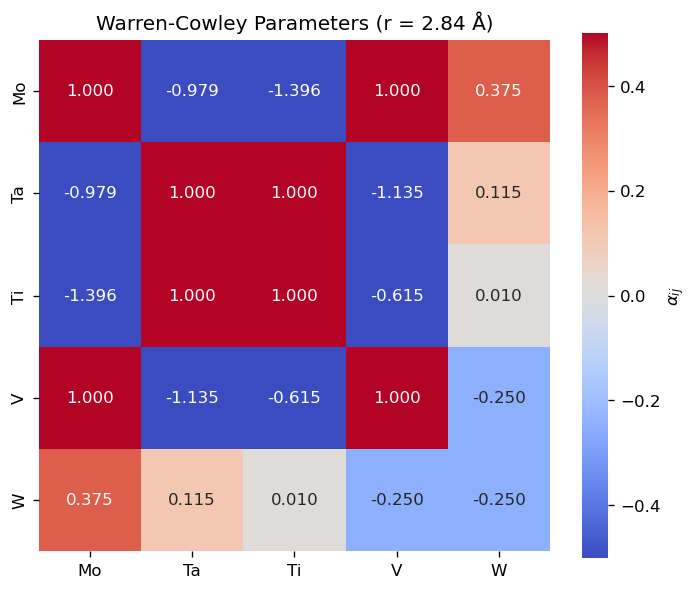

In [5]:
import seaborn as sns

plt.figure(figsize=(6, 5), dpi=120)
sns.heatmap(
    wc_matrix.astype(float), 
    annot=True, 
    fmt=".3f", 
    cmap="coolwarm", 
    vmin=-0.5, 
    vmax=0.5, 
    center=0,
    square=True,
    cbar_kws={'label': r'$\alpha_{ij}$'}
)

plt.title(f"Warren-Cowley Parameters (r = {r_cutoff:.2f} Å)", fontsize=12)
plt.tight_layout()
plt.savefig("warren_cowley_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()